In [3]:
!pip install -q transformers datasets accelerate evaluate gradio scikit-learn seaborn matplotlib pandas

In [4]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import evaluate
import gradio as gr
import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, Trainer, TrainingArguments, EarlyStoppingCallback,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


In [5]:
MODEL_NAME  = 'distilbert-base-uncased'
MAX_LEN     = 256
BATCH_SIZE  = 16
EPOCHS      = 3
LR          = 2e-5
SEED        = 42
OUTPUT_DIR  = '/content/models/hf_trainer'
LOG_DIR     = '/content/logs/hf_trainer'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR,    exist_ok=True)
print('Config ready')

Config ready


In [6]:
data = [
    ('Scientists confirm new cancer treatment shows 90% success rate', 0),
    ('Government secretly adding mind control chemicals to tap water', 1),
    ('Federal Reserve raises interest rates by 0.25% amid inflation', 0),
    ('Aliens have landed in New Mexico says anonymous source', 1),
    ('New climate report shows record high global temperatures', 0),
    ('Vaccines contain microchips to track your location', 1),
    ('Tech giant reports record quarterly earnings beating forecasts', 0),
    ('Celebrity fakes death to escape IRS investigation', 1),
    ('Study links regular Mediterranean diet to longer lifespan', 0),
    ('Mayor caught on camera confessing to secret society membership', 1),
    ('Electric vehicle adoption accelerates as battery costs fall', 0),
    ('Deep state operatives are controlling all major elections', 1),
    ('New bridge construction project will create thousands of jobs', 0),
    ('BREAKING doctors are hiding simple cure for all cancers', 1),
    ('University researchers discover new antibiotic for resistant bacteria', 0),
    ('Government plans to ban cash and force digital currency', 1),
    ('Stock markets close higher after positive economic data', 0),
    ('NASA faked all moon landings says former employee', 1),
    ('City council approves new affordable housing development plan', 0),
    ('Bill Gates funding secret program to reduce world population', 1),
]
# Replace with: df = pd.read_csv('train.csv')
df = pd.DataFrame(data, columns=['text','label'])

def clean(text):
    if not isinstance(text, str): return ''
    return re.sub(r'\s+', ' ', re.sub(r'http\S+', '', text)).strip()

df['text'] = df['text'].apply(clean)
df = df[df['text'].str.len() > 10].reset_index(drop=True)
print(f'Samples: {len(df)}')
print(df['label'].value_counts().rename({0:'Real',1:'Fake'}))

Samples: 20
label
Real    10
Fake    10
Name: count, dtype: int64


In [7]:
texts  = df['text'].tolist()
labels = df['label'].tolist()

X_tv, X_test, y_tv, y_test = train_test_split(
    texts, labels, test_size=0.1, stratify=labels, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.11, stratify=y_tv, random_state=SEED)

dd = DatasetDict({
    'train': Dataset.from_dict({'text':X_train,'label':y_train}),
    'val':   Dataset.from_dict({'text':X_val,  'label':y_val}),
    'test':  Dataset.from_dict({'text':X_test, 'label':y_test}),
})
print(dd)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16
    })
    val: Dataset({
        features: ['text', 'label'],
        num_rows: 2
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2
    })
})


In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Tokenizer: {MODEL_NAME}')

def tokenize_fn(batch):
    return tokenizer(batch['text'], max_length=MAX_LEN,
                     truncation=True, padding=False)

tokenized = dd.map(tokenize_fn, batched=True, remove_columns=['text'])
tokenized = tokenized.rename_column('label','labels')
tokenized.set_format('torch')
print('Tokenized dataset:', tokenized)
print('Example keys:', list(tokenized['train'][0].keys()))

Tokenizer: distilbert-base-uncased


Map:   0%|          | 0/16 [00:00<?, ? examples/s]

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

Tokenized dataset: DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16
    })
    val: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2
    })
})
Example keys: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [9]:
accuracy_metric = evaluate.load('accuracy')
f1_metric       = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)['accuracy']
    f1  = f1_metric.compute(predictions=preds, references=labels, average='weighted')['f1']
    return {'accuracy': acc, 'f1': f1}

print('Metrics callback ready')

Metrics callback ready


In [10]:
!pip install --upgrade transformers

In [13]:
model    = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2,
    id2label={0:'Real',1:'Fake'}, label2id={'Real':0,'Fake':1})
collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE * 2,
    learning_rate               = LR,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    lr_scheduler_type           = 'cosine',
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'accuracy',
    logging_dir                 = LOG_DIR,
    logging_steps               = 10,
    report_to                   = 'none',
    seed                        = SEED,
    fp16                        = torch.cuda.is_available(),
)

trainer = Trainer(
    model          = model,
    args           = training_args,
    train_dataset  = tokenized['train'],
    eval_dataset   = tokenized['val'],
    data_collator  = collator,
    compute_metrics= compute_metrics,
    callbacks      = [EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f'Best model saved to {OUTPUT_DIR}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.715962,0.000000,0.000000
2,No log,0.710261,0.500000,0.333333
3,No log,0.707418,0.500000,0.333333


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved to /content/models/hf_trainer


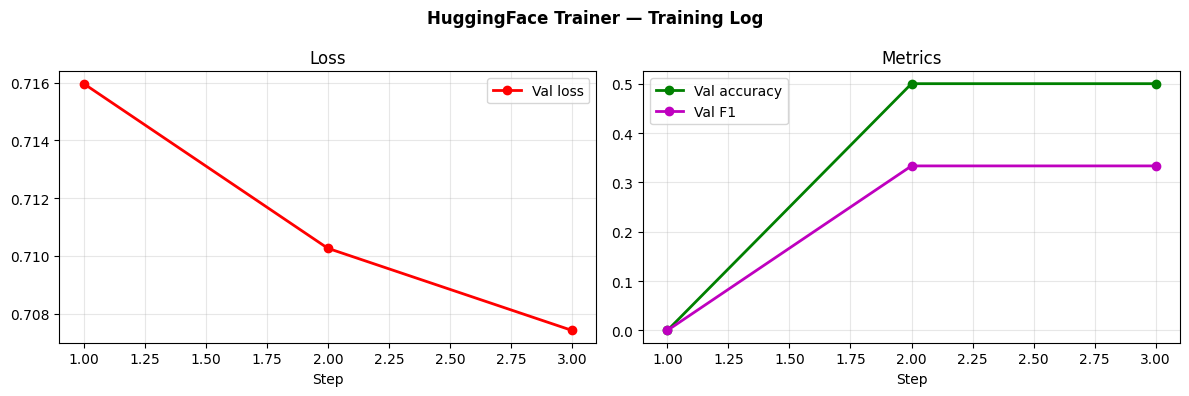

In [14]:
# Plot training log
log_df    = pd.DataFrame(trainer.state.log_history)
eval_log  = log_df[log_df.get('eval_loss', pd.Series(dtype=float)).notna()] if 'eval_loss' in log_df.columns else pd.DataFrame()
train_log = log_df[log_df['loss'].notna()] if 'loss' in log_df.columns else pd.DataFrame()

fig, axes = plt.subplots(1,2,figsize=(12,4))
fig.suptitle('HuggingFace Trainer — Training Log', fontweight='bold')
if not train_log.empty:
    axes[0].plot(train_log['step'], train_log['loss'], 'b-', lw=1.5, label='Train loss')
if not eval_log.empty:
    axes[0].plot(eval_log['step'], eval_log['eval_loss'], 'r-o', lw=2, label='Val loss')
    if 'eval_accuracy' in eval_log.columns:
        axes[1].plot(eval_log['step'], eval_log['eval_accuracy'], 'g-o', lw=2, label='Val accuracy')
    if 'eval_f1' in eval_log.columns:
        axes[1].plot(eval_log['step'], eval_log['eval_f1'], 'm-o', lw=2, label='Val F1')
for ax,title in zip(axes,['Loss','Metrics']):
    ax.set_title(title); ax.set_xlabel('Step'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Classification Report
              precision    recall  f1-score   support

        Real     1.0000    1.0000    1.0000         1
        Fake     1.0000    1.0000    1.0000         1

    accuracy                         1.0000         2
   macro avg     1.0000    1.0000    1.0000         2
weighted avg     1.0000    1.0000    1.0000         2



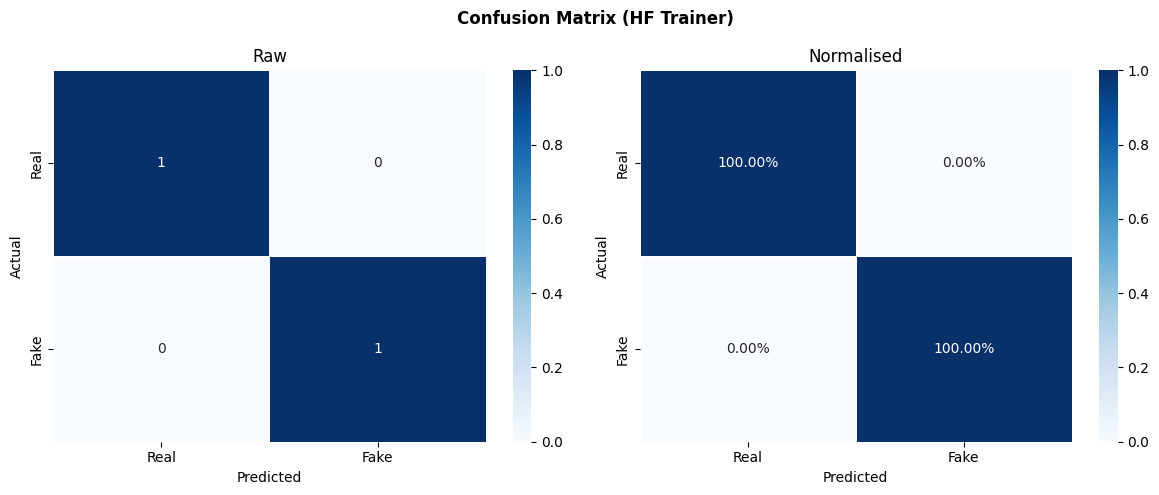

In [15]:
preds_out = trainer.predict(tokenized['test'])
y_pred    = np.argmax(preds_out.predictions, axis=1)
y_true    = preds_out.label_ids

print('Classification Report'); print('='*55)
print(classification_report(y_true, y_pred, target_names=['Real','Fake'], digits=4))

cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1,2,figsize=(12,5))
fig.suptitle('Confusion Matrix (HF Trainer)', fontweight='bold')
for ax,data,fmt,title in zip(axes,
    [cm, cm.astype(float)/cm.sum(axis=1,keepdims=True)],
    ['d','.2%'],['Raw','Normalised']):
    sns.heatmap(data,annot=True,fmt=fmt,cmap='Blues',
                xticklabels=['Real','Fake'],yticklabels=['Real','Fake'],
                ax=ax,linewidths=0.5)
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

In [16]:
deploy_model = AutoModelForSequenceClassification.from_pretrained(OUTPUT_DIR).to(DEVICE)
deploy_tok   = AutoTokenizer.from_pretrained(OUTPUT_DIR)
deploy_model.eval()

@torch.no_grad()
def classify(text):
    if not text.strip(): return 'Please enter some text.'
    enc   = deploy_tok(text, max_length=MAX_LEN, truncation=True,
                       padding='max_length', return_tensors='pt')
    enc   = {k:v.to(DEVICE) for k,v in enc.items()
             if k in ('input_ids','attention_mask','token_type_ids')}
    probs = torch.softmax(deploy_model(**enc).logits,1).cpu().numpy()[0]
    pred  = int(np.argmax(probs))
    return (f"{'FAKE' if pred else 'REAL'} | {probs[pred]*100:.1f}% confident\n\n"
            f'Real: {probs[0]*100:.1f}%  |  Fake: {probs[1]*100:.1f}%')

gr.Interface(
    fn=classify,
    inputs=gr.Textbox(label='News Headline or Article', lines=5),
    outputs=gr.Markdown(label='Result'),
    title='Fake News Detector (HF Trainer)',
    examples=[
        ['Federal Reserve holds rates steady as inflation cools.'],
        ['Scientists reveal Big Pharma hiding miracle cure for 20 years!'],
    ],
    theme=gr.themes.Soft()
).launch(share=True)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c14289af4ae58dc2b9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
